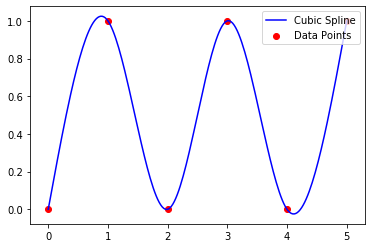

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x)
    A = np.zeros(n - 2)
    B = np.zeros(n - 2)
    C = np.zeros(n - 2)
    D = np.zeros(n - 2)
    for i in range(1, n - 1):
        A[i - 1] = h[i-1]
        B[i - 1] = 2*(h[i-1]+h[i])
        C[i - 1] = h[i]
        D[i - 1] = 6*((y[i+1]-y[i])/h[i]-(y[i]-y[i-1])/h[i-1])
    return A, B, C, D

def thomas_algorithm(a, b, c, d):
    n = len(b)
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

def evaluate_spline(x, y, M, x_eval):
    n = len(x)
    y_eval = np.zeros_like(x_eval)
    for j, xe in enumerate(x_eval):
        for i in range(n-1):
            if x[i] <= xe <= x[i+1]:
                break
        h_i = x[i+1] - x[i]
        term1 = M[i] * (x[i+1] - xe)**3 / (6 * h_i)
        term2 = M[i+1] * (xe - x[i])**3 / (6 * h_i)
        term3 = (y[i] - M[i]*h_i**2/6) * (x[i+1] - xe) / h_i
        term4 = (y[i+1] - M[i+1]*h_i**2/6) * (xe - x[i]) / h_i
        y_eval[j] = term1 + term2 + term3 + term4
    return y_eval

x = np.array([0, 1, 2, 3, 4, 5])
y = np.array([0, 1, 0, 1, 0, 1])
n = len(x)
a, b, c, d = setup_tridiagonal_matrix(x, y)
M_internal = thomas_algorithm(a, b, c, d)
M = np.zeros(n)
M[1:-1] = M_internal

x_eval = np.linspace(min(x), max(x), 200)
y_eval = evaluate_spline(x, y, M, x_eval)

plt.plot(x_eval, y_eval, color="blue", label="Cubic Spline")
plt.scatter(x, y, color="red", label="Data Points")
plt.legend()
plt.show()